In [36]:
import albumentations as A
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
import os
import random
from collections import defaultdict
from glob import glob

In [37]:
!gdown --fuzzy https://drive.google.com/file/d/1Su16aM-TjoWTCVpq_NPgMrRMkln36IbY/view?usp=drive_link

Downloading...
From (original): https://drive.google.com/uc?id=1Su16aM-TjoWTCVpq_NPgMrRMkln36IbY
From (redirected): https://drive.google.com/uc?id=1Su16aM-TjoWTCVpq_NPgMrRMkln36IbY&confirm=t&uuid=85c86675-aa43-4c82-84fa-e154e76fe690
To: /content/train.zip
100% 161M/161M [00:03<00:00, 45.6MB/s]


In [38]:
!unzip train.zip

Archive:  train.zip
replace train/Апельсин/4333204/02490d40ba1b4840aba17bce77e53865.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [39]:
os.listdir('/content/train')

['Бананы',
 'Лук',
 'Мандарины',
 'Капуста',
 'Апельсин',
 'Кабачки',
 'Картофель',
 'Киви',
 'Яблоки красные',
 'Томаты',
 'Груши',
 'Лимон',
 'Морковь',
 'Яблоки зелёные',
 'Огурцы']

In [40]:
class_to_idx = { "Апельсин": 0, "Бананы": 1, "Груши": 2, "Кабачки": 3, "Капуста": 4, "Картофель": 5, "Киви": 6, "Лимон": 7, "Лук": 8, "Мандарины": 9, "Морковь": 10, "Огурцы": 11, "Томаты": 12, "Яблоки зелёные": 13, "Яблоки красные": 14 }

In [41]:
# важно - зафиксировать все сиды
SEED = 9999
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [42]:
class MyDataset(Dataset):
    def __init__(self, images_filepaths, name2label, transform=None):
        self.images_filepaths = images_filepaths
        self.transform = transform
        self.name2label = name2label

    def __len__(self):
        return len(self.images_filepaths)

    def __getitem__(self, idx):
        image_filepath = self.images_filepaths[idx]
        image = cv2.imdecode(np.fromfile(image_filepath, dtype=np.uint8), cv2.IMREAD_UNCHANGED)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = self.name2label[os.path.normpath(image_filepath).split(os.sep)[-3]]
        if self.transform is not None:
            image = self.transform(image=image)['image']
        return image, label


def train_test_split_from_directory(root_path, folder2class, train_size=0.8):
    train, test = [], []
    class_to_images = defaultdict(list)

    for class_name in os.listdir(root_path):
        class_path = os.path.join(root_path, class_name)
        if not os.path.isdir(class_path):
            continue

        for subclass_name in os.listdir(class_path):
            subclass_path = os.path.join(class_path, subclass_name)
            if not os.path.isdir(subclass_path):
                continue
            # Глобальный класс = имя первой папки (class_name)
            class_name = folder2class.get(class_name, class_name)
            images = glob(os.path.join(subclass_path, '*.jpg')) + \
                     glob(os.path.join(subclass_path, '*.png')) + \
                     glob(os.path.join(subclass_path, '*.jpeg'))

            class_to_images[class_name].extend(images)
            #print(f"Class_name {class_name}, \tSubClass_name: {subclass_name}\t", f"ImagesLen {len(images)}")
            random.shuffle(images)
            split_idx = int(train_size * len(images))

            train.extend(images[:split_idx])
            test.extend(images[split_idx:])


    print("\n\n\n")
    # Равномерное разбиение по каждому классу
    # for cls_name, images in class_to_images.items():
    #     #print(cls_name, images)
    #     random.shuffle(images)
    #     split_idx = int(train_size * len(images))
    #     train.extend(images[:split_idx])
    #     test.extend(images[split_idx:])

    return train, test


In [43]:
dataset_path = '/content/train'
train, test = train_test_split_from_directory(dataset_path, class_to_idx)

len(train), len(test)

(7822, 1980)

In [44]:
from collections import Counter
import os

def count_classes(image_paths, class_to_idx):
    counts = Counter()
    for path in image_paths:
        class_name = os.path.normpath(path).split(os.sep)[-3]
        class_idx = class_to_idx[class_name]
        counts[class_idx] += 1
    return counts

train_counts = count_classes(train, class_to_idx)
test_counts  = count_classes(test, class_to_idx)

print()

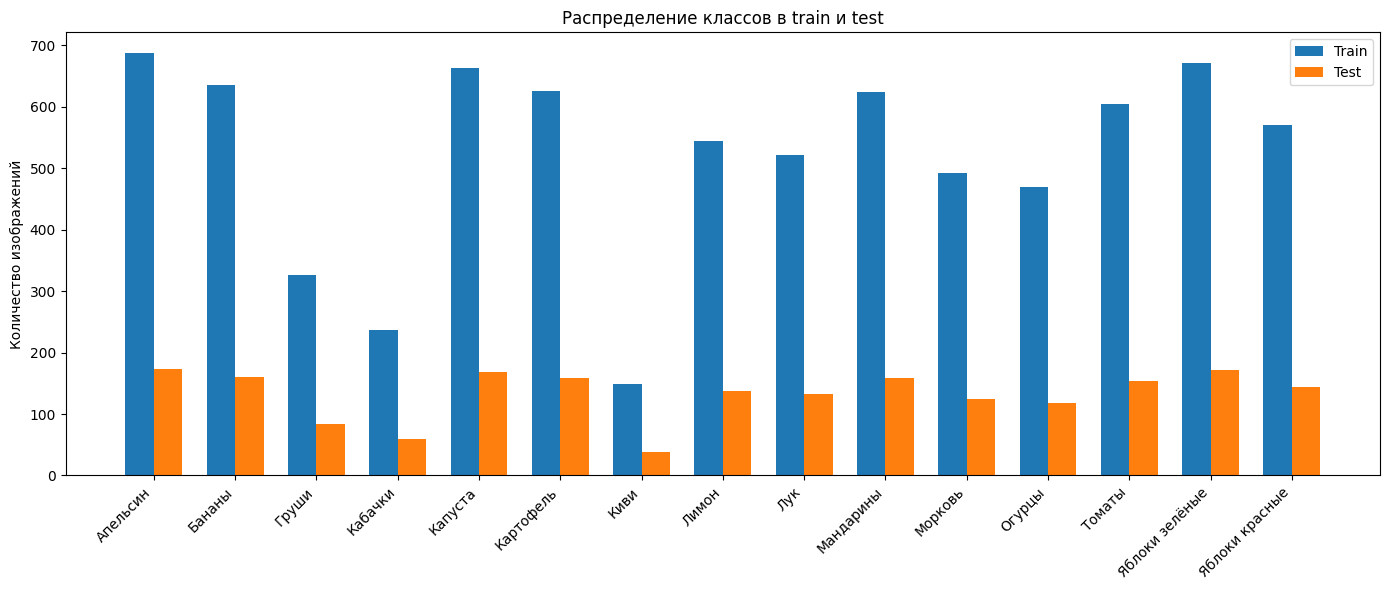

In [45]:
import matplotlib.pyplot as plt
import numpy as np

idx2class = {v: k for k, v in class_to_idx.items()}

classes = list(idx2class.keys())
class_names = [idx2class[i] for i in classes]
train_values = [train_counts.get(i, 0) for i in classes]
test_values  = [test_counts.get(i, 0) for i in classes]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, train_values, width, label='Train')
plt.bar(x + width/2, test_values,  width, label='Test')

plt.xticks(x, class_names, rotation=45, ha='right')
plt.ylabel('Количество изображений')
plt.title('Распределение классов в train и test')
plt.legend()
plt.tight_layout()
plt.show()


In [46]:
import pandas as pd

rows = []

for class_idx, class_name in idx2class.items():
    train_cnt = train_counts.get(class_idx, 0)
    test_cnt  = test_counts.get(class_idx, 0)
    total     = train_cnt + test_cnt

    test_ratio = test_cnt / total if total > 0 else 0

    rows.append({
        "Класс": class_name,
        "Train": train_cnt,
        "Test": test_cnt,
        "Total": total,
        "Test %": round(test_ratio * 100, 2)
    })

df = pd.DataFrame(rows)
df


,Класс,Train,Test,Total,Test %
0,Апельсин,687,174,861,20.21
1,Бананы,635,161,796,20.23
2,Груши,327,83,410,20.24
3,Кабачки,236,59,295,20.00
4,Капуста,663,169,832,20.31
5,Картофель,626,158,784,20.15
6,Киви,149,38,187,20.32
7,Лимон,544,137,681,20.12
8,Лук,522,132,654,20.18
9,Мандарины,625,159,784,20.28


In [47]:
from sklearn.utils.class_weight import compute_class_weight

# Создает массив меток номеров класса для массива данных
def labeler_classes(image_paths, class_to_idx):
  label_arr = np.zeros(len(image_paths), dtype = np.int32)
  for i, path in enumerate (image_paths):
    class_name = os.path.normpath(path).split(os.sep)[-3]
    label_arr[i] = class_to_idx[class_name]
  return label_arr


print(class_to_idx)
train_labels = labeler_classes(train, class_to_idx)
classes = np.array(classes)
class_weights = compute_class_weight(class_weight = 'balanced', classes = classes, y = train_labels)
class_weights = torch.tensor(class_weights, dtype = torch.float32)
print('Полученные веса для классов: ', class_weights)

{'Апельсин': 0, 'Бананы': 1, 'Груши': 2, 'Кабачки': 3, 'Капуста': 4, 'Картофель': 5, 'Киви': 6, 'Лимон': 7, 'Лук': 8, 'Мандарины': 9, 'Морковь': 10, 'Огурцы': 11, 'Томаты': 12, 'Яблоки зелёные': 13, 'Яблоки красные': 14}
Полученные веса для классов:  tensor([0.7590, 0.8212, 1.5947, 2.2096, 0.7865, 0.8330, 3.4998, 0.9586, 0.9990,
        0.8343, 1.0577, 1.1119, 0.8634, 0.7760, 0.9149])


In [48]:
# train_transforms = A.Compose([
#     A.Resize(224, 224),
#     A.HorizontalFlip(p=0.5),
#     A.VerticalFlip(p=0.5),
#     A.ColorJitter(p=0.5),
#     A.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225]),
#     A.ToTensorV2(),
# ])

# Validation transforms - deterministic
val_transforms = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    A.ToTensorV2(),
])

In [49]:
train_transforms = A.Compose([
    A.RandomResizedCrop((224, 224), scale=(0.7, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=75, p=0.5),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.RandomGamma(p=0.3),
    A.CLAHE(p=0.3),
    A.CoarseDropout(max_holes=4, max_height=50, max_width=50, p=0.3),
    A.GaussNoise(var_limit=(10, 50), p=0.2),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    A.ToTensorV2()
])


/tmp/ipython-input-613/310015494.py:9: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=50, max_width=50, p=0.3),
/tmp/ipython-input-613/310015494.py:10: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.2),


In [50]:
train_dataset = MyDataset(images_filepaths=train, name2label=class_to_idx, transform=train_transforms)
test_dataset = MyDataset(images_filepaths=test, name2label=class_to_idx, transform=val_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,  # Parallel loading
    pin_memory=True,  # Faster GPU transfer
    persistent_workers=True  # Keep workers alive
)
test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=1,  # Parallel loading
    pin_memory=True,  # Faster GPU transfer
    persistent_workers=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [52]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter("logs")

In [53]:
import numpy as np
import torch
from tqdm import tqdm

@torch.no_grad()
def evaluate(model, dataloader, loss_fn, device, desc="Val"):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    pbar = tqdm(dataloader, desc=desc, leave=False)
    for X_batch, y_batch in pbar:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        batch_size = y_batch.size(0)
        total_loss += loss.item() * batch_size

        y_pred = logits.argmax(dim=1)
        total_correct += (y_pred == y_batch).sum().item()
        total_samples += batch_size

        avg_loss = total_loss / max(total_samples, 1)
        acc = total_correct / max(total_samples, 1)
        pbar.set_postfix(loss=f"{avg_loss:.4f}", acc=f"{acc:.4f}")

    avg_loss = total_loss / max(total_samples, 1)
    accuracy = total_correct / max(total_samples, 1)
    return accuracy, avg_loss


def train_model(model, loss_fn, optimizer, scheduler, train_loader, val_loader, device, writer=None, n_epoch=3):
    num_iter = 0
    lrs = []

    for epoch in range(1, n_epoch + 1):
        model.train()

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{n_epoch}", leave=True)

        for X_batch, y_batch in pbar:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            # накопим метрики для прогресс-бара
            batch_size = y_batch.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            y_pred = logits.argmax(dim=1)
            total_correct += (y_pred == y_batch).sum().item()

            avg_loss = total_loss / max(total_samples, 1)
            acc = total_correct / max(total_samples, 1)

            # tqdm live-metrics
            pbar.set_postfix(train_loss=f"{avg_loss:.4f}", train_acc=f"{acc:.4f}")

            # логирование (по итерациям)
            num_iter += 1
            if writer is not None:
                writer.add_scalar("Loss/train", loss.item(), num_iter)
                writer.add_scalar("Accuracy/train", (y_pred == y_batch).float().mean().item(), num_iter)

        # Валидация (тоже с tqdm)
        val_acc, val_loss = evaluate(model, val_loader, loss_fn, device, desc=f"Val {epoch}/{n_epoch}")

        scheduler.step(val_loss)
        lrs.append(optimizer.param_groups[0]["lr"])

        if writer is not None:
            writer.add_scalar("Loss/val", val_loss, num_iter)
            writer.add_scalar("Accuracy/val", val_acc, num_iter)

        print(f"Epoch {epoch}/{n_epoch}: val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")
        print(lrs[-1])
    return model


In [54]:
class_weights = class_weights.to(device)

model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=15)
model.to(device)

# выбираем функцию потерь
loss_fn = torch.nn.CrossEntropyLoss(weight = class_weights, label_smoothing = 0.09)

# выбираем алгоритм оптимизации и learning_rate
learning_rate = 1e-3
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer = optimizer, mode = 'min', patience = 1)

In [55]:
from sklearn.model_selection import StratifiedKFold
from copy import deepcopy


skf = StratifiedKFold( n_splits = 5, shuffle = True, random_state = SEED)

ensemble_models = []

for fold, (train_idx, test_idx) in enumerate(skf.split(train, train_labels)):

  fold_train = [train[i] for i in train_idx]
  fold_test = [train[i] for i in test_idx]

  train_dataset = MyDataset(fold_train, name2label = class_to_idx,transform = train_transforms)
  test_dataset = MyDataset(fold_test, name2label = class_to_idx, transform = val_transforms)

  train_loader = DataLoader(
      train_dataset,
      batch_size=64,
      shuffle=True,
      num_workers=4,  # Parallel loading
      pin_memory=True,  # Faster GPU transfer
      persistent_workers=True  # Keep workers alive
  )
  test_loader = DataLoader(
      test_dataset,
      batch_size=12,
      shuffle=False,
      num_workers=1,  # Parallel loading
      pin_memory=True,  # Faster GPU transfer
      persistent_workers=True)
  model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=15)
  model.to(device)
  # выбираем функцию потерь
  loss_fn = torch.nn.CrossEntropyLoss(weight = class_weights, label_smoothing = 0.1)
  # выбираем алгоритм оптимизации и learning_rate
  learning_rate = 1e-3
  optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer = optimizer, mode = 'min', patience = 1)
  model = train_model(model, loss_fn, optimizer, scheduler, train_loader, test_loader, device, writer, n_epoch=20)

  ensemble_models.append(deepcopy(model))
  torch.save(model.state_dict(), f'ensemble_mode{fold}.pth')


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 1/20:   0%|          | 0/98 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_ration

Epoch 1/20: val_loss=1.1974  val_acc=0.7968
0.001


Epoch 2/20: 100%|██████████| 98/98 [01:07<00:00,  1.46it/s, train_acc=0.7409, train_loss=1.2743]


Epoch 2/20: val_loss=1.0168  val_acc=0.8837
0.001


Epoch 3/20: 100%|██████████| 98/98 [01:06<00:00,  1.47it/s, train_acc=0.8128, train_loss=1.1107]


...

Epoch 18/20: val_loss=0.8620  val_acc=0.9399
1e-05


Epoch 19/20: 100%|██████████| 98/98 [01:06<00:00,  1.47it/s, train_acc=0.9714, train_loss=0.7173]


Epoch 19/20: val_loss=0.8619  val_acc=0.9412
1e-05


Epoch 20/20: 100%|██████████| 98/98 [01:06<00:00,  1.47it/s, train_acc=0.9751, train_loss=0.7151]


Epoch 20/20: val_loss=0.8608  val_acc=0.9393
1e-05


In [56]:
#model = train_model(model, loss_fn, optimizer, scheduler, train_loader, test_loader, device, writer, n_epoch=18)

In [57]:
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix

@torch.no_grad()
def sklearn_report(model, dataloader, device, idx2class=None, digits=4):
    model.eval()

    y_true, y_pred = [], []

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device, non_blocking=True)

        logits = model(X_batch)
        preds = logits.argmax(dim=1).cpu().numpy()

        y_pred.append(preds)
        y_true.append(y_batch.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    # names for report
    if idx2class is None:
        target_names = None
        labels = None
    else:
        labels = sorted(idx2class.keys())
        target_names = [idx2class[i] for i in labels]

    rep = classification_report(
        y_true, y_pred,
        labels=labels,
        target_names=target_names,
        digits=digits,
        zero_division=0
    )
    print(rep)

In [58]:
sklearn_report(model, test_loader, device, idx2class=idx2class)

                precision    recall  f1-score   support

      Апельсин     0.9328    0.9124    0.9225       137
        Бананы     0.9760    0.9606    0.9683       127
         Груши     0.9474    0.8308    0.8852        65
       Кабачки     0.9216    1.0000    0.9592        47
       Капуста     0.9924    0.9850    0.9887       133
     Картофель     0.9664    0.9200    0.9426       125
          Киви     0.7879    0.8667    0.8254        30
         Лимон     0.9182    0.9266    0.9224       109
           Лук     0.8649    0.9231    0.8930       104
     Мандарины     0.9350    0.9200    0.9274       125
       Морковь     0.9048    0.9596    0.9314        99
        Огурцы     0.9579    0.9681    0.9630        94
        Томаты     0.9669    0.9669    0.9669       121
Яблоки зелёные     0.9635    0.9851    0.9742       134
Яблоки красные     0.9189    0.8947    0.9067       114

      accuracy                         0.9393      1564
     macro avg     0.9303    0.9346    0.9318 

In [59]:
# !ls
# !rm -rf train
# !rm -rf logs
# !rm train.zip

In [60]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
ReduceLROnPlateau.get_last_lr(scheduler)

[1e-05]

In [61]:
!gdown --fuzzy https://drive.google.com/file/d/1hBRx8H_hkqm-O7ItZzkdNrfAqLB3ZE_N/view?usp=sharing
!gdown --fuzzy https://drive.google.com/file/d/15xud_rJkONbaTN1U3SV8I72YjfgIeuoU/view?usp=sharing

Downloading...
From: https://drive.google.com/uc?id=1hBRx8H_hkqm-O7ItZzkdNrfAqLB3ZE_N
To: /content/sample_submission.csv
100% 100k/100k [00:00<00:00, 106MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=15xud_rJkONbaTN1U3SV8I72YjfgIeuoU
From (redirected): https://drive.google.com/uc?id=15xud_rJkONbaTN1U3SV8I72YjfgIeuoU&confirm=t&uuid=c4bccb01-92f0-4f65-a82b-4a3c5e7c337b
To: /content/test_images.zip
100% 40.9M/40.9M [00:01<00:00, 25.2MB/s]


In [62]:
!unzip test_images.zip

Archive:  test_images.zip
replace test_images/00068bff986746d78eb3851ffabfe7cb.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [63]:
test_images_dir = "test_images"
submission_path = "sample_submission.csv"
output_path = "submission.csv"

In [64]:
submission = pd.read_csv(submission_path)

model.eval()
pred_labels = []

with torch.no_grad():
    for image_id in tqdm(submission["image_id"], desc="Predicting"):
        image_path = os.path.join(test_images_dir, image_id)

        image = cv2.imdecode(
            np.fromfile(image_path, dtype=np.uint8),
            cv2.IMREAD_COLOR
        )
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Когда мы хотим сделать предсказание, нам нужно знать, а какие были преобразования при обучении/тестировании
        if val_transforms is not None:
            image = val_transforms(image=image)["image"]
        pred_idx = []
        image = image.unsqueeze(0).to(device)
        for model in ensemble_models:
          logits = model(image)
          pred_idx.append( logits.argmax(dim=1).item())
        pred_idx = torch.tensor(pred_idx)
        #print("\n\n", pred_idx, "\n\n")

        pred_labels.append(int(torch.mode(pred_idx, dim = 0)[0]))
        #print(pred_labels[-1], '\n')

Predicting: 100%|██████████| 2503/2503 [03:13<00:00, 12.95it/s]


In [65]:
submission["label"] = pred_labels
submission.to_csv(output_path, index=False)

submission.head()


,image_id,label
0,fd343552326b42c5a62c192f32549dc7.jpg,2
1,445ca69812cf44f581cc8a89223af277.jpg,7
2,570626ce4d8f41edb8088f49d40a2195.jpg,7
3,02d4acba92f343d798adcb4958fe684b.jpg,11
4,2d4b8e8f38534a39b0d02c440e917b83.jpg,12


In [66]:
pred_labels = []
logits = model(image)
pred_idx = logits.argmax(dim=1).item()

pred_labels.append(int(torch.tensor(pred_idx)))
print(pred_labels)

[3]
